# Análisis de los datos

In [2]:
from extraccion import minioFunctions as mf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

Se presenta un análisis detallado de las variables regresoras que serán empleadas para el modelo que predice la probabilidad de incendio dada una latitud y longitud, así como las correlaciones entre ellas y con la variable objetivo

### **Caracteristicas de las variables**

In [3]:
l_f = []
for k in [2022, 2023,2024, 2025]:
    print(f"Analizando el año {k}:")
    dataf = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/cleaned/modelo_General_{k}.parquet", type="df")
    l_f.append(dataf)
dataFrame = pd.concat(l_f, ignore_index=True)

Analizando el año 2022:
Dataframe importado correctamente
Analizando el año 2023:
Dataframe importado correctamente
Analizando el año 2024:
Dataframe importado correctamente
Analizando el año 2025:
Dataframe importado correctamente


In [4]:
df_final = dataFrame.copy()

**COMPOSICIÓN DEL DATASET**

Las variables son:

In [5]:
print(f"Variables: {df_final.columns}")

Variables: Index(['lat', 'lon', 'date', 'final', 'elevacion_centro', 'grados',
       'porcentaje', 'temp_mean', 'temp_max', 'temp_min', 'humidity_mean',
       'precipitation', 'wind_speed_max', 'wind_gusts_max', 'pressure_mean',
       'cloud_cover', 'radiation', 'evapotranspiration', 'sunshine_seconds',
       'NDVI', 'NDWI'],
      dtype='str')


Total de filas y proporción de incendios y no incendios:

In [6]:
total = len(df_final)
total_incendios = len(df_final[df_final['final'] == 1])
total_no_incendios = len(df_final[df_final['final'] == 0])
print(f"La longitud total de los datos es de: {total}")
print(f"Proporción de incendios: {np.round(total_incendios * 100 / total, 2)} %")
print(f"Proporción de no incendios: {np.round(total_no_incendios * 100 / total, 2)} %")

La longitud total de los datos es de: 71444
Proporción de incendios: 3.76 %
Proporción de no incendios: 96.24 %


Representación primeras filas del dataset:

In [7]:
print(df_final.head(10))

         lat        lon       date  final  elevacion_centro     grados  \
0  34.940922  32.478487 2022-06-22      0        232.554901  15.533253   
1  34.951754  32.483892 2022-04-22      0        251.324463   7.779768   
2  34.959053  32.521256 2022-08-22      0        273.531555   7.937498   
3  34.961834  32.444368 2022-06-22      0        320.596954  16.206121   
4  34.967268  32.435256 2022-04-22      0        274.819000  10.585607   
5  34.977097  32.470616 2022-07-22      0        128.463608  23.943657   
6  34.980346  32.392628 2022-07-22      0        383.755280  16.072320   
7  34.987872  32.542161 2022-03-22      0        368.368774   7.168215   
8  34.992342  32.432700 2022-02-22      0        156.731934  10.129428   
9  34.992755  32.417797 2022-09-22      0        268.785706  11.545950   

   porcentaje  temp_mean  temp_max  temp_min  ...  precipitation  \
0   27.794965       25.7      30.5      20.5  ...            0.0   
1   13.662323       16.1      21.8       9.4  ...

**VARIABLE OBJETIVO**

La varible objetivo es una variable binaria --> 0 indica no-incendio y 1, incendio.

In [8]:
print(df_final['final'].unique())

[0 1]


**INFORMACIÓN DEL TIPO DE VARIABLES**

In [9]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 71444 entries, 0 to 71443
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 71444 non-null  float64       
 1   lon                 71444 non-null  float64       
 2   date                71444 non-null  datetime64[us]
 3   final               71444 non-null  int64         
 4   elevacion_centro    71444 non-null  float64       
 5   grados              71444 non-null  float64       
 6   porcentaje          71444 non-null  float64       
 7   temp_mean           71444 non-null  float64       
 8   temp_max            71444 non-null  float64       
 9   temp_min            71444 non-null  float64       
 10  humidity_mean       71444 non-null  float64       
 11  precipitation       71444 non-null  float64       
 12  wind_speed_max      71444 non-null  float64       
 13  wind_gusts_max      71444 non-null  float64       
 14  p

**INFORMACIÓN ESTADÍSTICA DE LAS VARIABLES**

Evaluar la distribución de la variable objetivo (porque es binaria) y de la fecha, y su información estadística resulta irrelevante.

Eliminamos también la latitud y longitud, ya que posteriormente se realizará un gráfico en forma de mapa.

Más tarde se hará un análisis de incendios y de datos basado en los meses.

In [10]:
df = df_final.drop(columns = ['final', 'date', 'lat', 'lon']) 
df.describe()

,elevacion_centro,grados,porcentaje,temp_mean,temp_max,temp_min,humidity_mean,precipitation,wind_speed_max,wind_gusts_max,pressure_mean,cloud_cover,radiation,evapotranspiration,sunshine_seconds,NDVI,NDWI
count,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000
mean,412.587686,6.523116,11.841478,11.643895,16.351846,7.223571,71.561251,2.139403,16.589919,36.632575,968.513308,54.584038,14.513500,2.729884,31156.473745,0.445047,-0.436926
std,429.766258,7.755343,14.865904,8.951396,9.975310,8.174689,15.778236,5.493580,6.642947,13.372159,47.876438,33.316980,8.582497,2.038158,16106.798699,0.246807,0.210546
min,-4.915385,0.001124,0.001961,-25.600000,-22.800000,-30.000000,9.000000,0.000000,1.600000,6.500000,646.800000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000
25%,104.385832,0.950033,1.658272,5.400000,9.400000,1.500000,61.000000,0.000000,11.700000,27.000000,945.200000,25.000000,7.300000,1.040000,21195.302500,0.235958,-0.604346
50%,247.203384,3.341336,5.838352,11.500000,16.100000,7.400000,74.000000,0.000000,15.600000,34.900000,984.400000,58.000000,13.960000,2.240000,34052.300000,0.442799,-0.447827
75%,604.038635,9.415966,16.583523,18.100000,23.500000,13.100000,84.000000,1.600000,20.400000,43.900000,1003.100000,86.000000,22.070000,4.150000,44140.607500,0.652084,-0.297466
max,3606.814453,61.469063,183.940168,39.000000,48.000000,33.500000,100.000000,171.200000,63.400000,145.400000,1045.800000,100.000000,32.850000,12.360000,76364.840000,1.000000,1.000000


**DISTRIBUCIÓN DE LAS VARIABLES NUMÉRICAS**

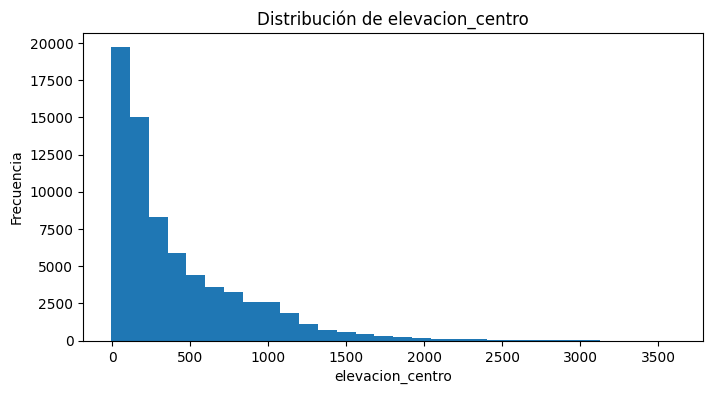

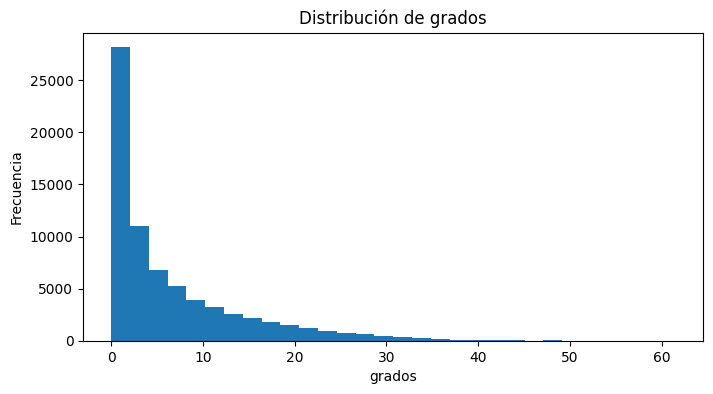

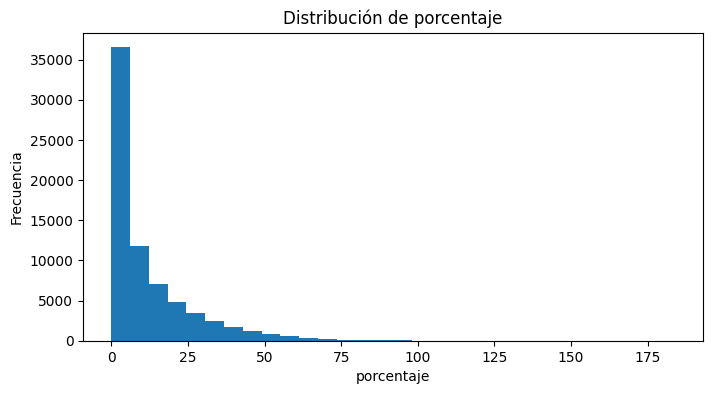

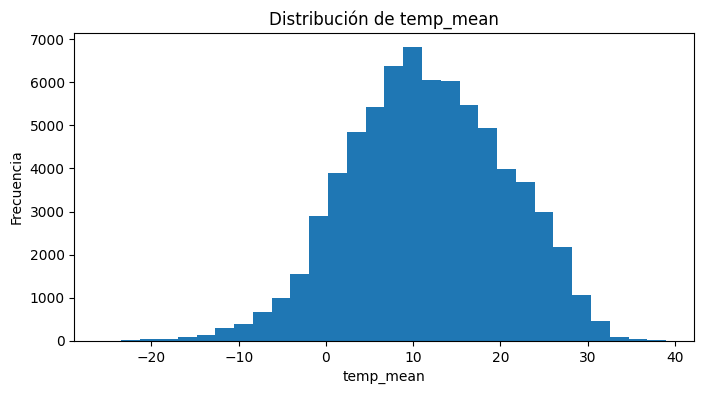

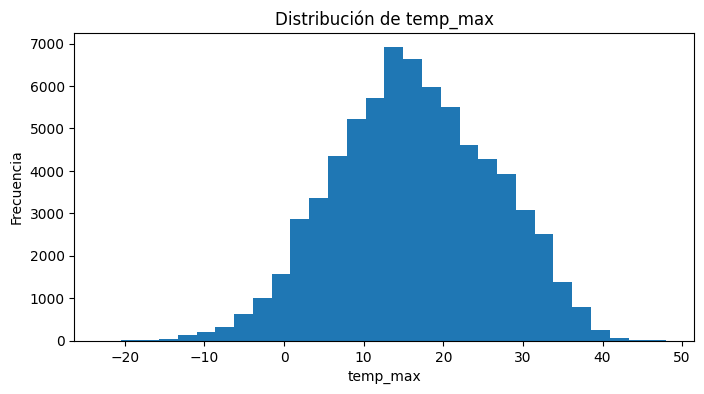

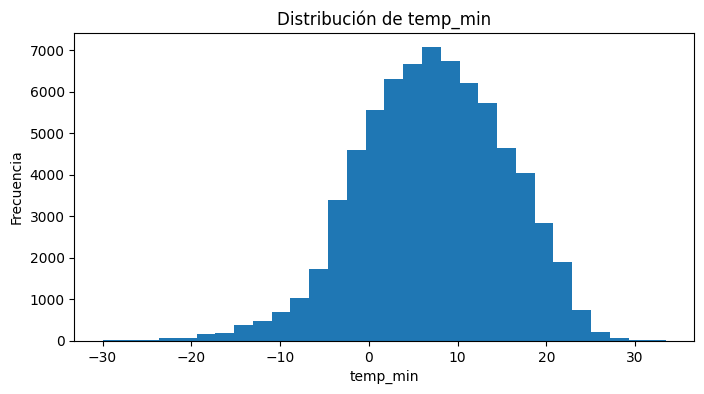

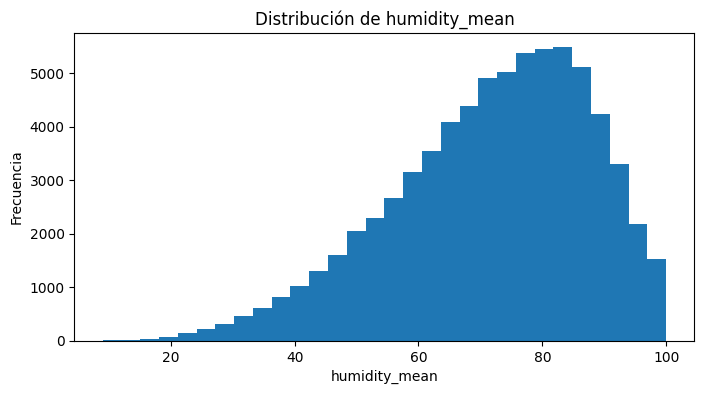

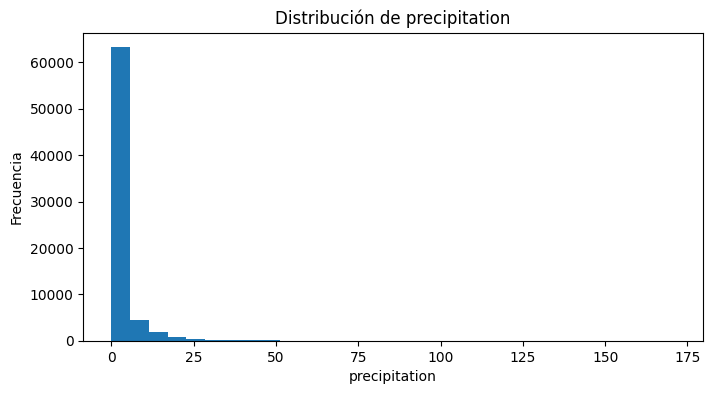

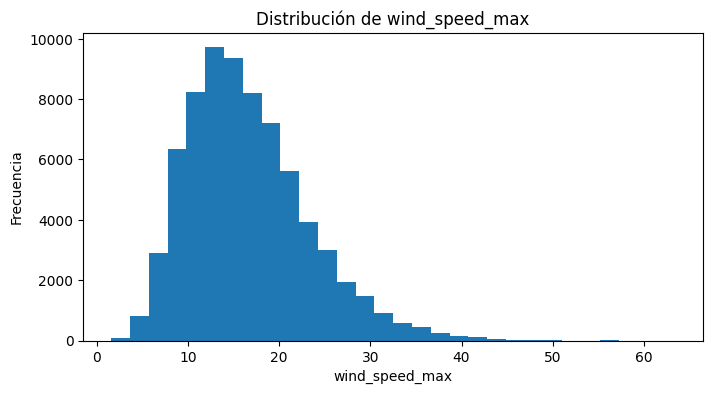

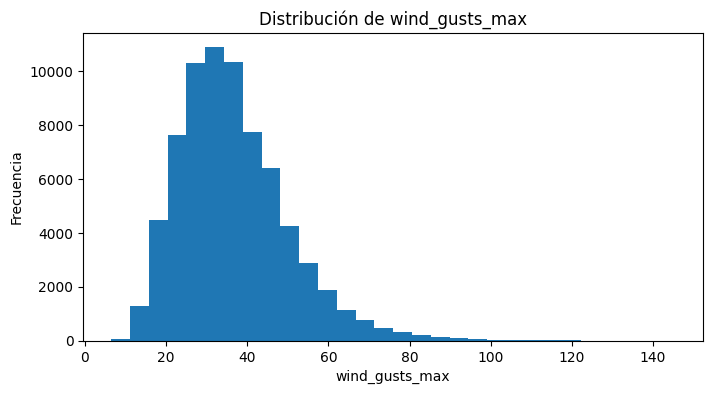

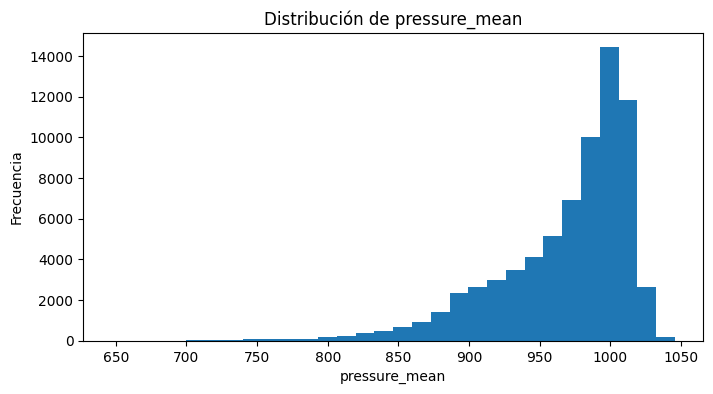

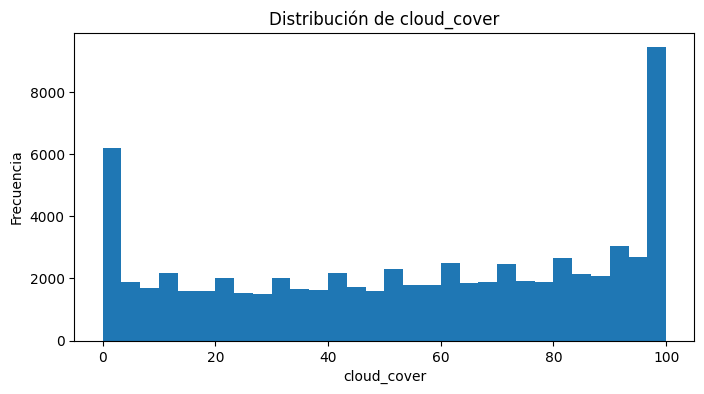

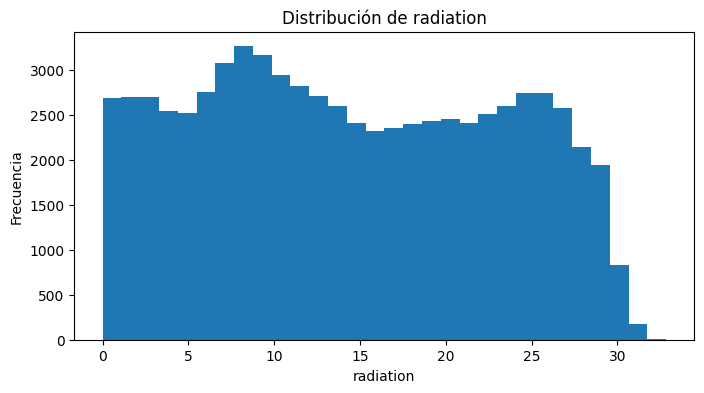

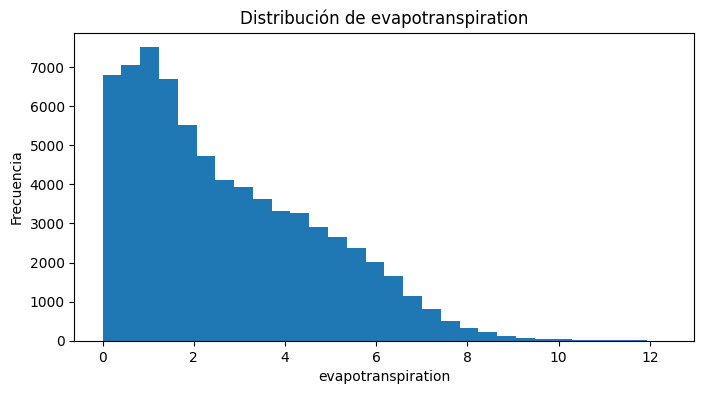

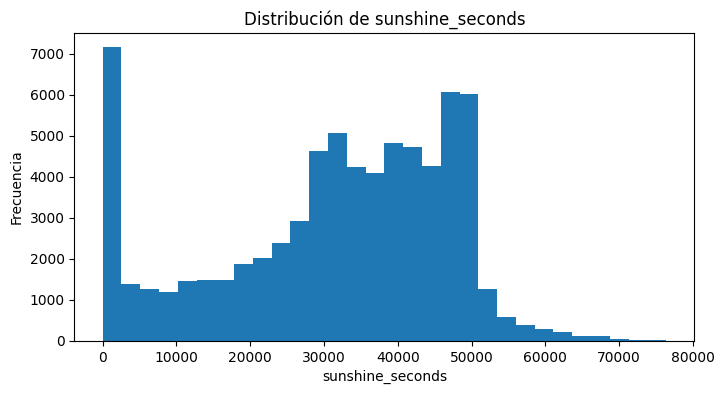

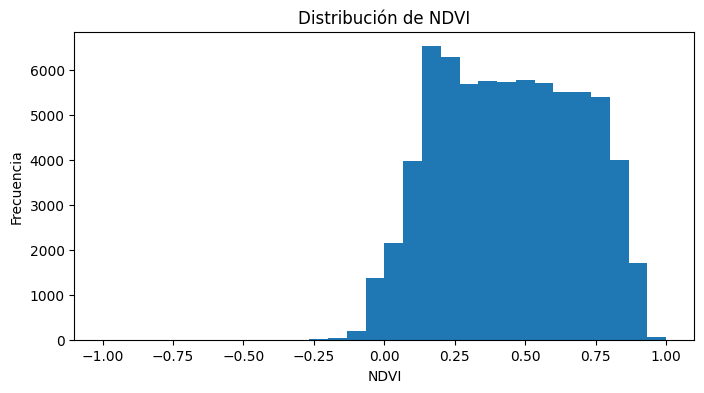

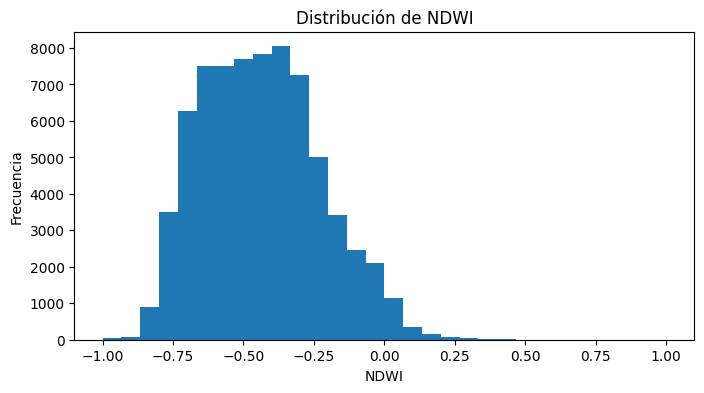

In [11]:
for col in df.columns:
    plt.figure(figsize=(8, 4))
    df[col].hist(bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(False)
    plt.show()

**ANÁLISIS DE LA PRESENCIA DE OUTLIERS**

**Outliers en datos de incendio:**

In [18]:
def detectar_outliers(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    outliers = data[(data[columna] < limite_inf) | (data[columna] > limite_sup)]
    return outliers, limite_inf, limite_sup

df_inc = df_final[df_final['final'] == 1].drop(columns = ['lat', 'lon', 'date', 'final'])
for col in df_inc.columns:
    outliers, limite_inf, limite_sup = detectar_outliers(df_inc, col)
    print(f"Variable {col}: Detectados {len(outliers)} outliers (fuera del rango {limite_inf:.2f} - {limite_sup:.2f})", '\n')

Variable elevacion_centro: Detectados 137 outliers (fuera del rango -558.74 - 1139.43) 

Variable grados: Detectados 154 outliers (fuera del rango -12.75 - 22.79) 

Variable porcentaje: Detectados 171 outliers (fuera del rango -22.47 - 40.15) 

Variable temp_mean: Detectados 23 outliers (fuera del rango -1.85 - 44.95) 

Variable temp_max: Detectados 28 outliers (fuera del rango 3.30 - 52.10) 

Variable temp_min: Detectados 13 outliers (fuera del rango -6.89 - 37.61) 

Variable humidity_mean: Detectados 3 outliers (fuera del rango 10.00 - 90.00) 

Variable precipitation: Detectados 373 outliers (fuera del rango 0.00 - 0.00) 

Variable wind_speed_max: Detectados 45 outliers (fuera del rango 1.30 - 34.90) 

Variable wind_gusts_max: Detectados 60 outliers (fuera del rango 8.00 - 71.20) 

Variable pressure_mean: Detectados 97 outliers (fuera del rango 884.10 - 1080.90) 

Variable cloud_cover: Detectados 40 outliers (fuera del rango -49.00 - 87.00) 

Variable radiation: Detectados 13 outlier

Los valores tan bajos en los rangos (principalmente destaca elevacion_centro), representan que la mayoría de observaciones tienen valores bajos.

**Outliers en datos de no incendio:**

In [19]:
def detectar_outliers(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    outliers = data[(data[columna] < limite_inf) | (data[columna] > limite_sup)]
    return outliers, limite_inf, limite_sup

df_no_inc = df_final[df_final['final'] == 0].drop(columns = ['lat', 'lon', 'date', 'final'])
for col in df_inc.columns:
    outliers, limite_inf, limite_sup = detectar_outliers(df_no_inc, col)
    print(f"Variable {col}: Detectados {len(outliers)} outliers (fuera del rango {limite_inf:.2f} - {limite_sup:.2f})", '\n')

Variable elevacion_centro: Detectados 2592 outliers (fuera del rango -648.02 - 1361.61) 

Variable grados: Detectados 4016 outliers (fuera del rango -11.70 - 22.08) 

Variable porcentaje: Detectados 4466 outliers (fuera del rango -20.65 - 38.91) 

Variable temp_mean: Detectados 270 outliers (fuera del rango -13.40 - 36.20) 

Variable temp_max: Detectados 206 outliers (fuera del rango -11.35 - 43.45) 

Variable temp_min: Detectados 456 outliers (fuera del rango -15.55 - 29.65) 

Variable humidity_mean: Detectados 649 outliers (fuera del rango 31.50 - 115.50) 

Variable precipitation: Detectados 10376 outliers (fuera del rango -2.55 - 4.25) 

Variable wind_speed_max: Detectados 1332 outliers (fuera del rango -1.45 - 33.35) 

Variable wind_gusts_max: Detectados 1667 outliers (fuera del rango 2.10 - 68.50) 

Variable pressure_mean: Detectados 2278 outliers (fuera del rango 857.55 - 1089.95) 

Variable cloud_cover: Detectados 0 outliers (fuera del rango -63.00 - 177.00) 

Variable radiation

**DISTRIBUCIÓN DE LOS INCENDIOS Y DE LOS DATOS POR LATITUD Y LONGITUD**

Se quiere evaluar si hay una distribución equitativa de los datos, como se pretendía con la obtención de los datos de no incendio, así como evaluar las zonas donde el riesgo de incendio es mayor.

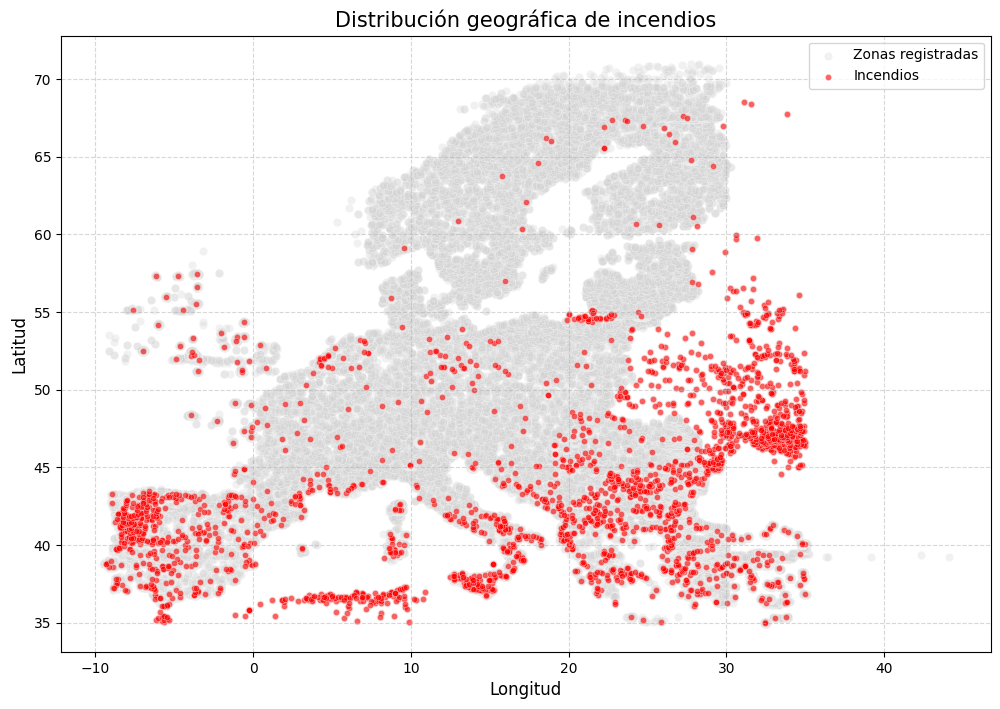

In [59]:
plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_final, x='lon', y='lat', color='lightgrey', alpha=0.3, label='Zonas registradas')

sns.scatterplot(data=df_final[df_final['final'] == 1], x='lon', y='lat', color='red', alpha=0.6, s=20, label='Incendios')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**DISTRIBUCIÓN DE INCENDIOS POR MESES**

Se quiere evaluar la distribución de los incendios por meses, para conocer qué meses presentan un mayor riesgo de incendio.

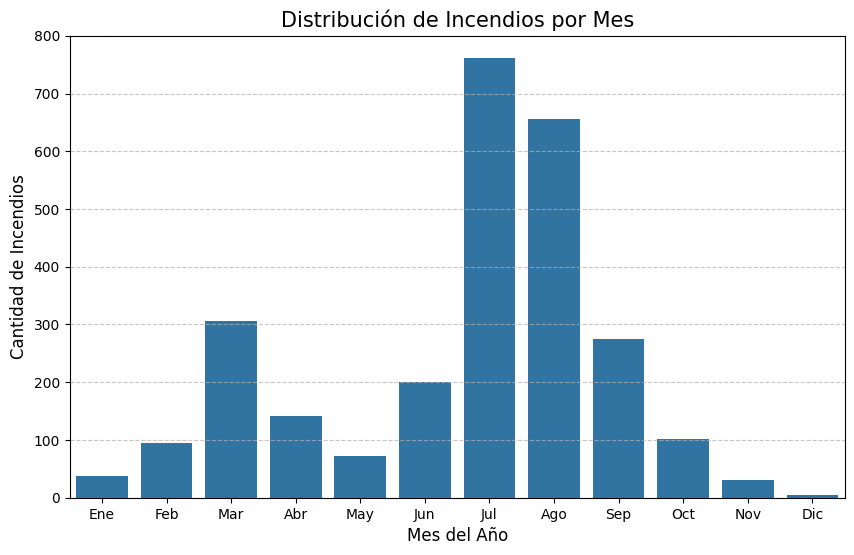

In [ ]:
df_final['month'] = df_final['date'].dt.month
df_incendios = df_final[df_final['final'] == 1]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_incendios, x='month')

plt.title('Distribución de incendios por mes', fontsize=15)
plt.xlabel('Mes del año', fontsize=12)
plt.ylabel('Cantidad de incendios', fontsize=12)
plt.xticks(ticks=range(0, 12), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Se observa que la mayoría de incendios se concentran en julio y agosto, principalmente.

**DISTRIBUCIÓN DE LOS DATOS POR MES**

Queremos evaluar si la distribución de los datos es equitativa tras la obtención de datos de no incendio.

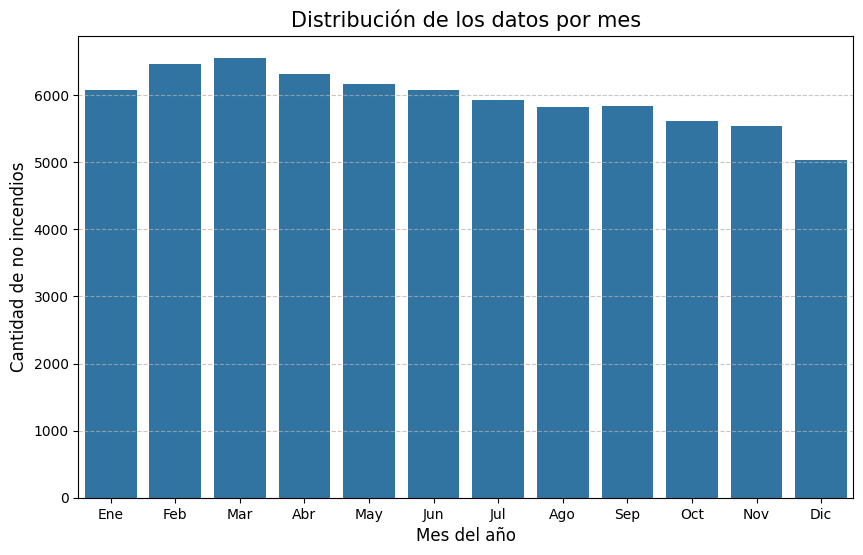

In [56]:
df_final['month'] = df_final['date'].dt.month

plt.figure(figsize=(10, 6))
sns.countplot(data=df_final, x='month')

plt.title('Distribución de los datos por mes', fontsize=15)
plt.xlabel('Mes del año', fontsize=12)
plt.ylabel('Cantidad de no incendios', fontsize=12)
plt.xticks(ticks=range(0, 12), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**CORRELACIONES ENTRE LAS VARIABLES REGRESORAS**

In [36]:
df2 = df_final.drop(columns=['final', 'lat', 'lon', 'date']) #No nos interesan lat, lon, ni date porque no serán empleadas en los modelos
df2.corr().style.background_gradient(cmap='coolwarm')

,elevacion_centro,grados,porcentaje,temp_mean,temp_max,temp_min,humidity_mean,precipitation,wind_speed_max,wind_gusts_max,pressure_mean,cloud_cover,radiation,evapotranspiration,sunshine_seconds,NDVI,NDWI
elevacion_centro,1.000000,0.541051,0.533669,-0.124868,-0.092679,-0.154506,-0.090123,0.035268,-0.204040,0.068592,-0.984681,-0.044557,0.098373,0.016404,0.055280,-0.073650,0.061044
grados,0.541051,1.000000,0.996273,-0.022411,-0.016991,-0.022093,-0.015997,0.063698,-0.178055,0.097660,-0.535627,-0.024194,0.067777,0.016439,0.038711,0.123011,-0.100343
porcentaje,0.533669,0.996273,1.000000,-0.026753,-0.021566,-0.026707,-0.013531,0.063910,-0.176945,0.095684,-0.527877,-0.021027,0.064158,0.013056,0.036086,0.113939,-0.090621
temp_mean,-0.124868,-0.022411,-0.026753,1.000000,0.984446,0.977070,-0.558250,-0.063514,0.062812,0.061097,0.127136,-0.414242,0.724171,0.849570,0.606921,0.311547,-0.371179
temp_max,-0.092679,-0.016991,-0.021566,0.984446,1.000000,0.933568,-0.620800,-0.114580,0.012949,0.012132,0.102174,-0.487989,0.768718,0.876741,0.667227,0.288671,-0.356121
temp_min,-0.154506,-0.022093,-0.026707,0.977070,0.933568,1.000000,-0.449306,0.000278,0.111680,0.107556,0.150841,-0.317807,0.627293,0.768394,0.506202,0.328611,-0.383093
humidity_mean,-0.090123,-0.015997,-0.013531,-0.558250,-0.620800,-0.449306,1.000000,0.333881,-0.035712,-0.051146,0.059191,0.634348,-0.710171,-0.793023,-0.662521,-0.008691,0.069381
precipitation,0.035268,0.063698,0.063910,-0.063514,-0.114580,0.000278,0.333881,1.000000,0.180918,0.258169,-0.079775,0.348667,-0.260731,-0.230023,-0.344120,0.049378,-0.044921
wind_speed_max,-0.204040,-0.178055,-0.176945,0.062812,0.012949,0.111680,-0.035712,0.180918,1.000000,0.865040,0.159342,0.137577,-0.069973,0.057721,-0.107827,-0.030394,0.027491
wind_gusts_max,0.068592,0.097660,0.095684,0.061097,0.012132,0.107556,-0.051146,0.258169,0.865040,1.000000,-0.115803,0.135790,-0.011890,0.079300,-0.065507,0.008865,-0.001400


<Axes: >

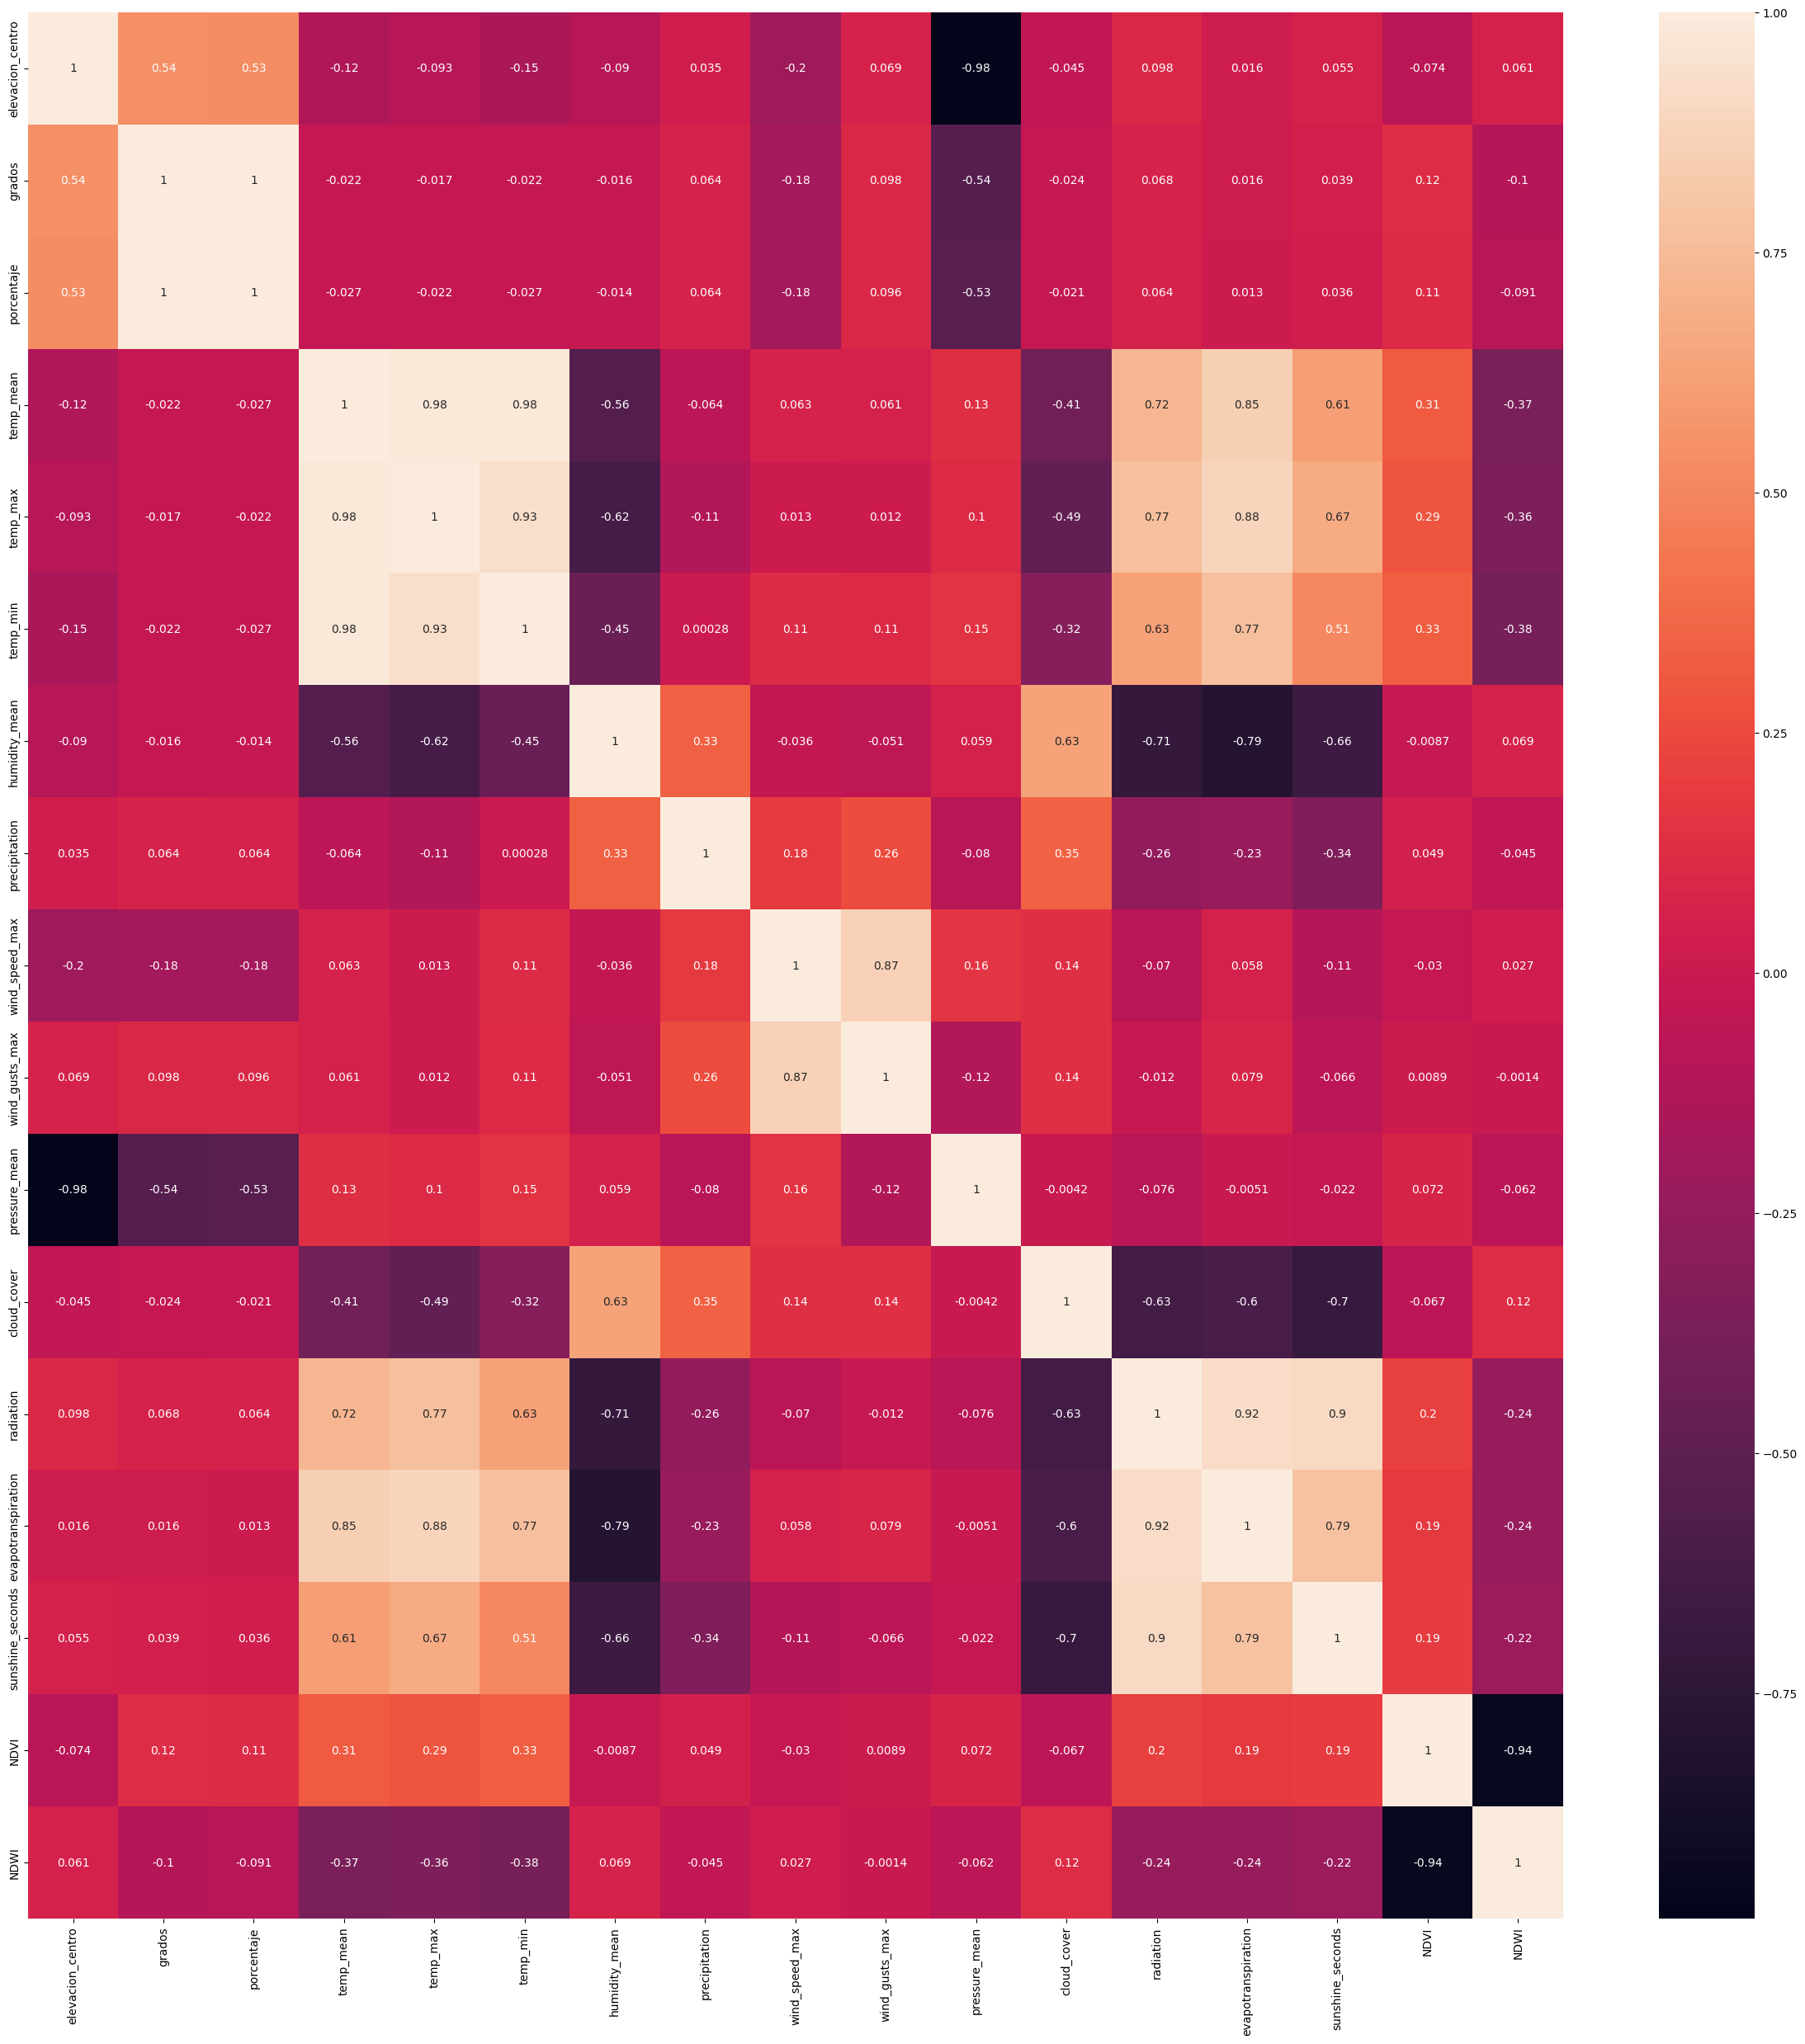

In [37]:
plt.figure(figsize=(30, 30))
sns.heatmap(df2.corr(), annot=True)

**Conclusiones:**

Se observa que hay muchas variables correlacionadas. Destacan:
1. **grados y porcentaje**, con una **correlación de 1**.
2. Las variables que representan la temperatura (**temp_max, temp_min y temp_mean**), con una correlación casi **cercana a 1**.
3. **pressure_mean y elevacion_centro**, con correlación negativa (**-0.98**).
4. **NDVI y NDWI**, con correlación negativa (valor **-0.94**).
5. La correlación de **evapotranspiration y radiation** (con valor **0.92**).
6. La correlación de **radiation con sunshine_seconds** (con valor **0.9**).
7. La correlación de **wind_speed_max y wind_gusts_max**, con una correlación de **0.87**. 
8. **evapotranspiration con temp_mean y temp_max** (con una correlación aproximada de **0.85**). Y de **0.77** con **temp_min**.
9. **evapotranspiration con humidity_mean** (valor **-0.79**).
10. **evapotranspiration con sunshine_seconds** (valor **0.79**).
11. **temp_mean y temp_max con radiation** (valor aproximado de **0.75**).

La variable evapotranspiration, por tanto, es la que más correlacionada está con el resto de variables. 

También sería importante seleccionar una entre grados o porcentaje, ya que representan lo mismo, entre NDVI y NDWI, entre pressure_mean y elevacion_centro, una entre las dos variables que representan el viento, y una entre todas las variables que representan la temperatura. 

El resto de correlaciones son menores a 0.7.

**CORRELACIÓN DE LAS VARIABLES REGRESORAS CON LA VARIABLE OBJETIVO**

In [38]:
df3 = df_final.drop(columns = ['lat', 'lon', 'date'])
correlaciones = df3.corr()
corr_objetivo = correlaciones['final'].drop(labels=['final']).sort_values(ascending=False)
df_corr_final = corr_objetivo.to_frame(name='Coeficiente de correlación')
df_corr_final

,Coeficiente de correlación
evapotranspiration,0.264050
temp_max,0.213916
temp_mean,0.202668
radiation,0.184124
temp_min,0.181588
sunshine_seconds,0.155969
wind_speed_max,0.058896
wind_gusts_max,0.055445
pressure_mean,0.038100
NDWI,0.013193


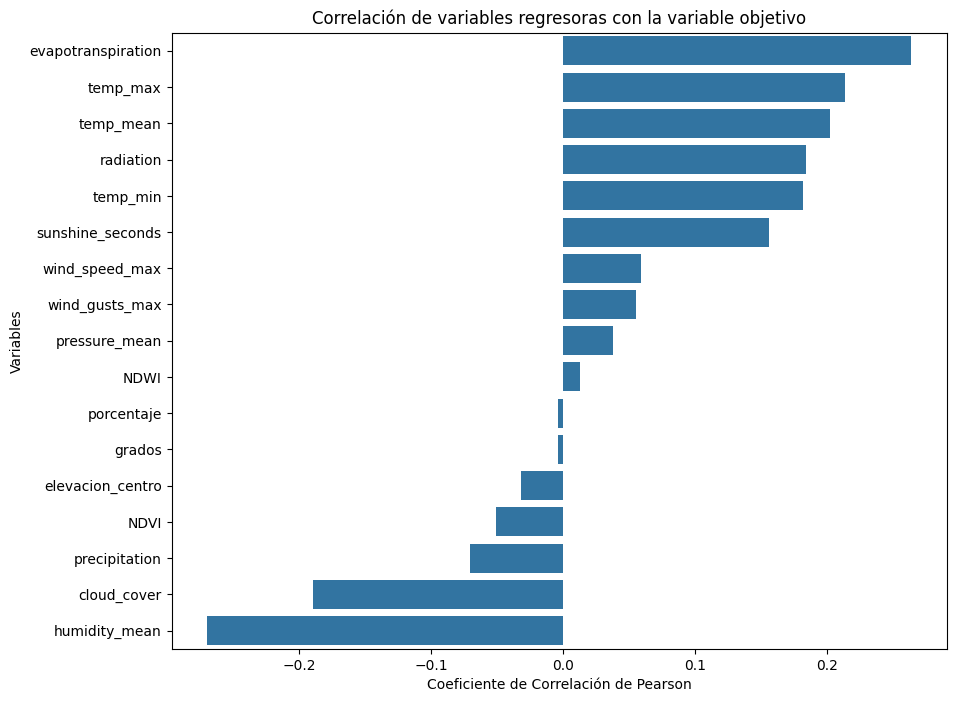

In [39]:
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_objetivo.values, y=corr_objetivo.index)
plt.title('Correlación de variables regresoras con la variable objetivo')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Variables')
plt.show()

**Conclusión:**

Se observa que las variables más correlacionadas con la variable objetivo son evapotranspiration, temp_max, temp_min, temp_mean, radiation, sunshine_seconds (estas con una correlación positiva), y cloud_cover y humidity_mean (con una correlación negativa).